In [1]:
# Project Goal
# Convert the data
# Aggregate to the monthly level
# Limit the period to 2000–2025
# Create Monthly Passenger Traffic at SFO by using Matplolib & Seaborn
# Average passenger traffic by month of the year
# Show COVID Impact on Passenger Traffic
# Using Scikit-learn create a training model
# 2026 Passengers Forecast

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('Air_Traffic_Passenger_Statistics.csv')

# convert the date
df['Activity Period Start Date'] = pd.to_datetime(
    df['Activity Period Start Date'],
    errors='coerce'
)

# aggregate to the monthly level.
monthly = (df.groupby('Activity Period Start Date')['Passenger Count']
             .sum()
             .sort_index())
# We limit the period to 2000–2025
monthly = monthly['2000-01-01':'2025-11-01']
monthly.head()

Activity Period Start Date
2000-01-01    2781129
2000-02-01    2725393
2000-03-01    3294029
2000-04-01    3392617
2000-05-01    3508679
Name: Passenger Count, dtype: int64

In [3]:
df = pd.read_csv('Air_Traffic_Passenger_Statistics.csv')

# convert the date
df['Activity Period Start Date'] = pd.to_datetime(
    df['Activity Period Start Date'],
    errors='coerce'
)

# aggregate to the monthly level.
monthly = (df.groupby('Activity Period Start Date')['Passenger Count']
             .sum()
             .sort_index())
# We limit the period to 2000–2025
monthly = monthly['2000-01-01':'2025-11-01']
monthly.head()

Activity Period Start Date
2000-01-01    2781129
2000-02-01    2725393
2000-03-01    3294029
2000-04-01    3392617
2000-05-01    3508679
Name: Passenger Count, dtype: int64

In [4]:
# Check
monthly.index.min(), monthly.index.max(), len(monthly)
# We bring it to a monthly frequency
monthly = monthly.asfreq('MS')

In [5]:
# Frequency check
monthly = monthly.asfreq('MS')   # MS = Month Start
monthly.head(), monthly.tail()

(Activity Period Start Date
 2000-01-01    2781129
 2000-02-01    2725393
 2000-03-01    3294029
 2000-04-01    3392617
 2000-05-01    3508679
 Freq: MS, Name: Passenger Count, dtype: int64,
 Activity Period Start Date
 2025-07-01    5269263
 2025-08-01    4824285
 2025-09-01    4421622
 2025-10-01    4795986
 2025-11-01    4295692
 Freq: MS, Name: Passenger Count, dtype: int64)

In [6]:
# Checking passes
monthly.isna().sum()

0

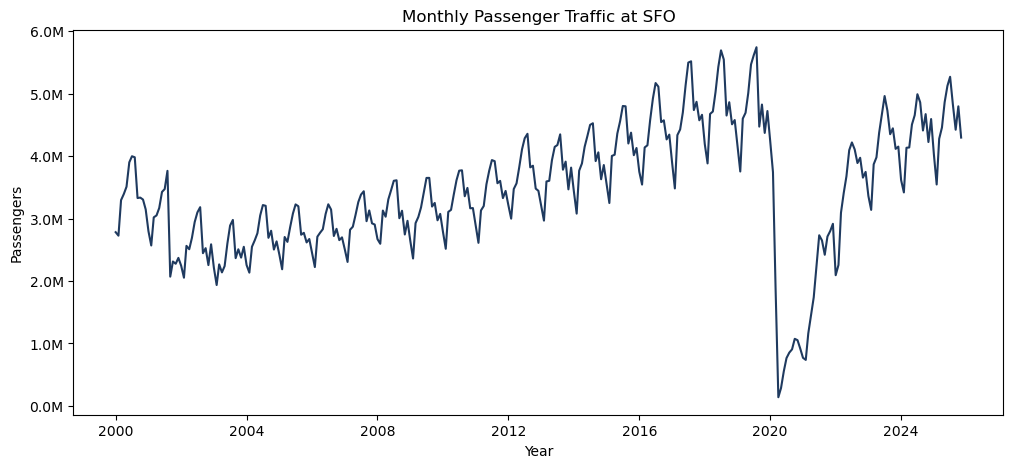

In [7]:
# matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly.values, color='#1F3A5F')

plt.title('Monthly Passenger Traffic at SFO')
plt.xlabel('Year')
plt.ylabel('Passengers')

import matplotlib.ticker as ticker

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

plt.show()

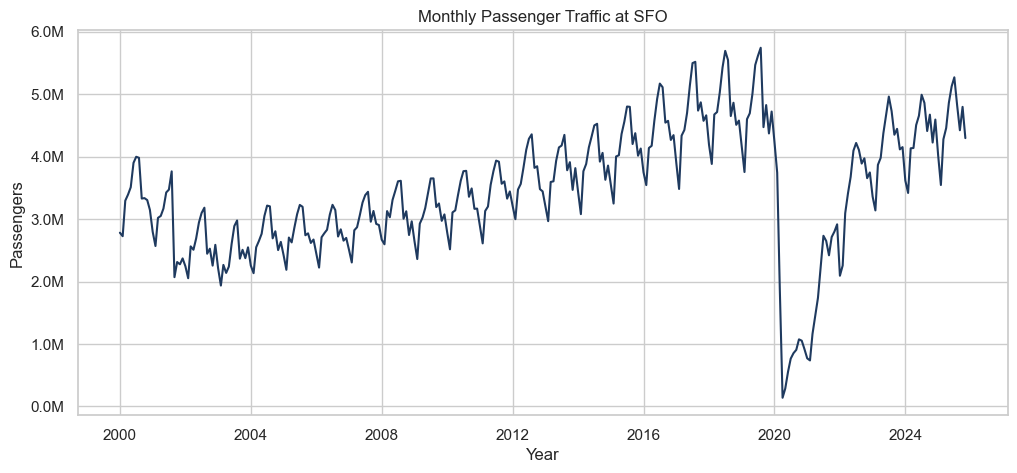

In [8]:
# seaborn
import seaborn as sns

sns.set(style='whitegrid')

plt.figure(figsize=(12,5))
sns.lineplot(x=monthly.index, y=monthly.values, color='#1F3A5F')

plt.title('Monthly Passenger Traffic at SFO')
plt.xlabel('Year')
plt.ylabel('Passengers')

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

plt.show()

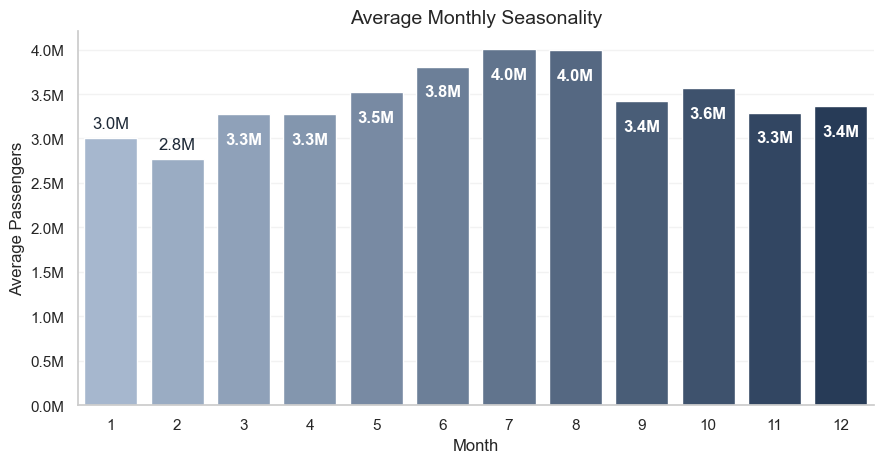

In [9]:
# Average passenger traffic by month of the year

monthly_df = monthly.to_frame(name='Passengers')   # convert Series to DataFrame for easier manipulation
monthly_df['Month'] = monthly_df.index.month       # extract month number from datetime index

seasonality = monthly_df.groupby('Month')['Passengers'].mean()  # compute average passengers for each month

plt.figure(figsize=(9,4.8))  # set figure size (dashboard-friendly ratio)

# rich corporate blue gradient (light → dark)
palette = sns.color_palette("blend:#9FB6D5,#1F3A5F", 12)

ax = sns.barplot(
    x=seasonality.index,
    y=seasonality.values,
    hue=seasonality.index,   # assign hue to match x to enable palette
    palette=palette,
    legend=False             # hide redundant legend
)

plt.title('Average Monthly Seasonality', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Average Passengers')

# format y-axis in millions
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

# soft grid similar to BI tools
ax.grid(axis='y', alpha=0.25)
ax.grid(axis='x', visible=False)

# add labels on bars
max_val = seasonality.max()  # store max value for relative positioning

for p in ax.patches:
    h = p.get_height()                       # bar height (value)
    x = p.get_x() + p.get_width()/2          # horizontal center of the bar

    label = f'{h/1e6:.1f}M'                  # convert to millions for display

    # small bars — place label above
    if h < max_val * 0.8:
        ax.text(x, h + max_val*0.02,
                label,
                ha='center',
                va='bottom',
                color='#1F2A38')
    # large bars — place label inside
    else:
        ax.text(x, h - max_val*0.05,
                label,
                ha='center',
                va='top',
                color='white',
                fontweight='bold')

sns.despine()            # remove top and right borders for cleaner look
plt.tight_layout()       # adjust spacing to prevent clipping
plt.show()

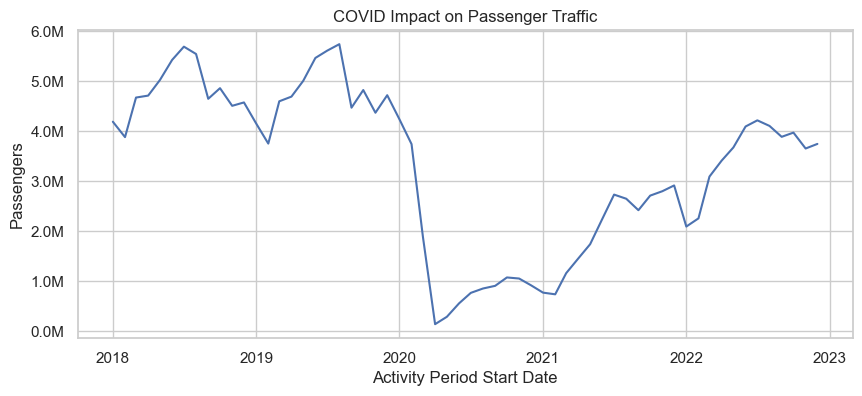

In [10]:
# Let's see the COVID effect
covid = monthly['2018':'2022']

plt.figure(figsize=(10,4))
sns.lineplot(x=covid.index, y=covid.values)

plt.title('COVID Impact on Passenger Traffic')

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

plt.ylabel('Passengers')

plt.show()

In [11]:
# Convert Series → DataFrame
ts = monthly.to_frame(name='Passengers')

In [12]:
# lag_1 — last month
# lag_12 — same month a year ago
ts['lag_1']  = ts['Passengers'].shift(1)
ts['lag_12'] = ts['Passengers'].shift(12)

In [13]:
# Moving averages
ts['roll_mean_3']  = ts['Passengers'].rolling(3).mean()
ts['roll_mean_12'] = ts['Passengers'].rolling(12).mean()

In [14]:
# Calendar signs
ts['month'] = ts.index.month
ts['year']  = ts.index.year

In [15]:
# Removing rows with NaN (due to lags)
ts = ts.dropna()

In [16]:
ts.head()

,Passengers,lag_1,lag_12,roll_mean_3,roll_mean_12,month,year
Activity Period Start Date,,,,,,,
2001-01-01,2795924,3145674.0,2781129.0,3.081767e+06,3.392186e+06,1,2001
2001-02-01,2568400,2795924.0,2725393.0,2.836666e+06,3.379104e+06,2,2001
2001-03-01,3018631,2568400.0,3294029.0,2.794318e+06,3.356154e+06,3,2001
2001-04-01,3049643,3018631.0,3392617.0,2.878891e+06,3.327573e+06,4,2001
2001-05-01,3168255,3049643.0,3508679.0,3.078843e+06,3.299204e+06,5,2001


In [17]:
# Train/test split
train = ts.iloc[:-12]
test  = ts.iloc[-12:]

In [18]:
# Separate X and y
X_train = train.drop('Passengers', axis=1)
y_train = train['Passengers']

X_test = test.drop('Passengers', axis=1)
y_test = test['Passengers']

In [19]:
# Train the model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [20]:
# Forecast for test
y_pred = model.predict(X_test)

In [21]:
# Quality assessment
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae  = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 173242.95333333337
RMSE: 191048.48061740588


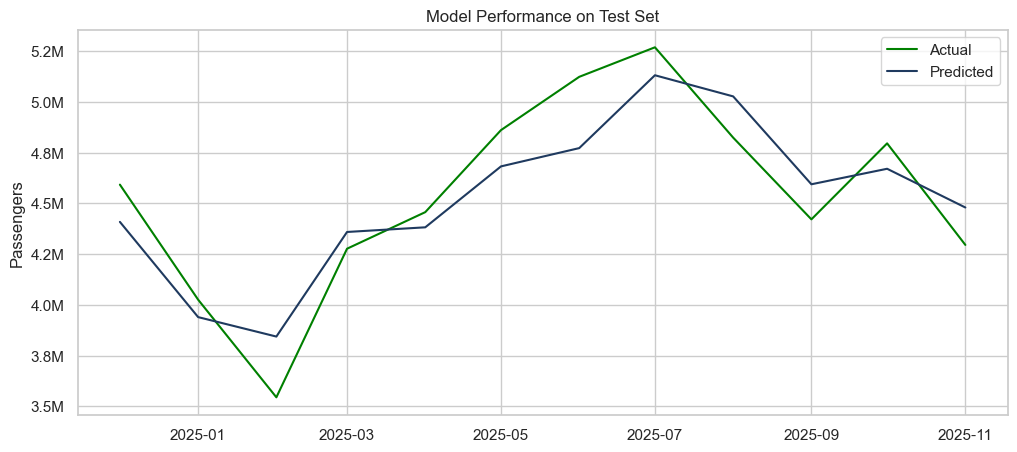

In [56]:
# Model Performance on Test Set
import matplotlib.ticker as ticker

plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test.values,
         label='Actual', color='green')

plt.plot(y_test.index, y_pred,
         label='Predicted', color='#1F3A5F')

plt.title('Model Performance on Test Set')
plt.legend()

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

plt.ylabel('Passengers')

plt.show()

In [23]:
# Create future dates
future_dates = pd.date_range(
    start='2026-01-01',
    periods=12,
    freq='MS'
)

In [24]:
# Ready-made forecasting function
last_data = ts.copy()

future_preds = []

for date in future_dates:

    last_row = last_data.iloc[-1]

    new_row = {
        'lag_1':  last_row['Passengers'],
        'lag_12': last_data.iloc[-12]['Passengers'],
        'roll_mean_3':  last_data['Passengers'].iloc[-3:].mean(),
        'roll_mean_12': last_data['Passengers'].iloc[-12:].mean(),
        'month': date.month,
        'year':  date.year
    }

    X_new = pd.DataFrame([new_row])
    pred  = model.predict(X_new)[0]

    future_preds.append(pred)

    # Adding a prediction to the story
    last_data.loc[date] = [pred] + list(new_row.values())

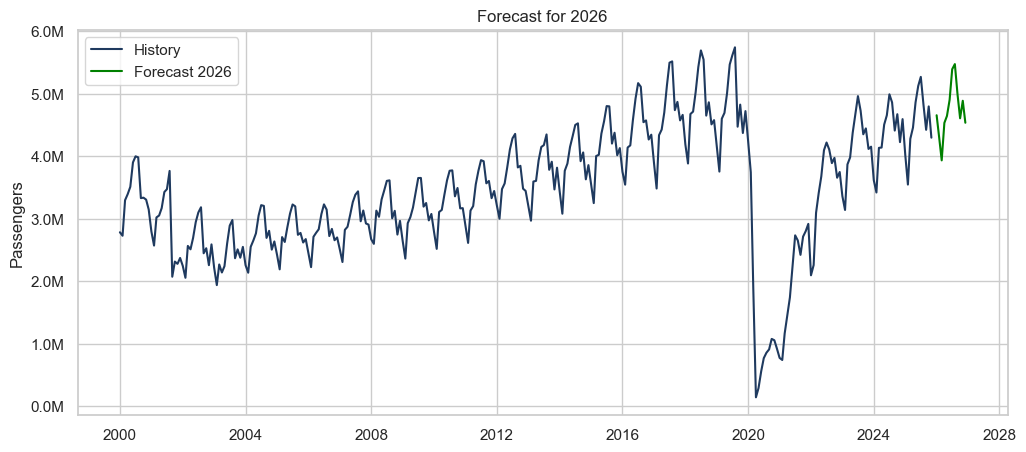

In [25]:
# 2026 Forecast
plt.figure(figsize=(12,5))

plt.plot(monthly.index, monthly.values,
         label='History', color='#1F3A5F')

plt.plot(future_dates, future_preds,
         label='Forecast 2026', color='green')

plt.legend()
plt.title('Forecast for 2026')

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

plt.ylabel('Passengers')

plt.show()

In [26]:
# Feature importance
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

roll_mean_3     0.738620
lag_12          0.150897
lag_1           0.091144
month           0.007213
roll_mean_12    0.007034
year            0.005091
dtype: float64


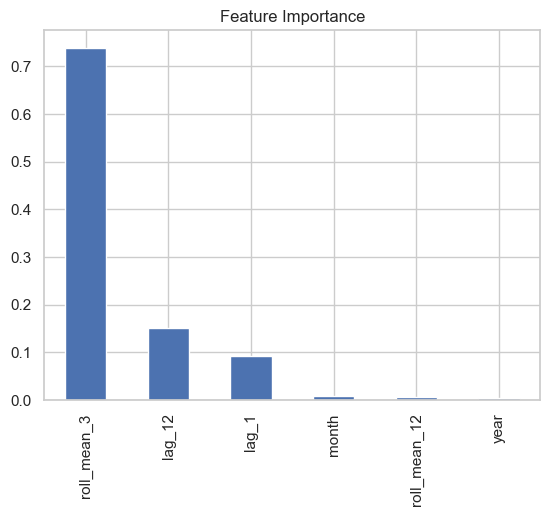

In [27]:
importance.plot(kind='bar')
plt.title('Feature Importance')
plt.show()

In [28]:
# Baseline: Seasonal Naive (t = t−12)
# Seasonal Naive baseline: predict using same month last year
y_pred_naive = y_test.copy()

# For each date in the test, we take the value from full ts 12 months earlier
y_pred_naive[:] = ts.loc[y_test.index - pd.DateOffset(months=12), 'Passengers'].values

In [29]:
# Let's calculate metrics for the baseline and compare them with RandomForest
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae_naive  = mean_absolute_error(y_test, y_pred_naive)
rmse_naive = root_mean_squared_error(y_test, y_pred_naive)

mae_rf  = mean_absolute_error(y_test, y_pred)
rmse_rf = root_mean_squared_error(y_test, y_pred)

print("Seasonal Naive  MAE:", mae_naive)
print("Seasonal Naive RMSE:", rmse_naive)
print("RandomForest   MAE:", mae_rf)
print("RandomForest  RMSE:", rmse_rf)

Seasonal Naive  MAE: 232601.0
Seasonal Naive RMSE: 281299.46233388595
RandomForest   MAE: 173242.95333333337
RandomForest  RMSE: 191048.48061740588


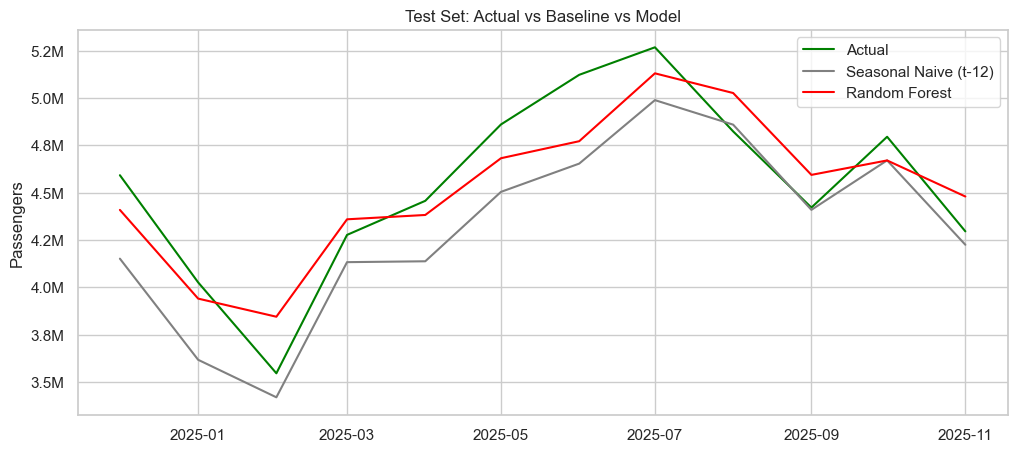

In [30]:
# Actual vs Naive vs RF
plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test.values, label='Actual', color='green')
plt.plot(y_test.index, y_pred_naive.values, label='Seasonal Naive (t-12)', color='gray')
plt.plot(y_test.index, y_pred, label='Random Forest', color='red')

plt.title('Test Set: Actual vs Baseline vs Model')
plt.legend()

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
plt.ylabel('Passengers')

plt.show()

In [31]:
## As a baseline, I used a seasonal naive forecast where each month is predicted as the passenger count from 
## the same month in the previous year (t−12). The Random Forest model is evaluated against this baseline using MAE and RMSE.
## A seasonal naive baseline (t−12) was used for comparison.
## The Random Forest model demonstrates improved accuracy by incorporating short-term dependencies (lag features) and moving averages, 
## allowing it to capture both seasonal patterns and local trends.

In [32]:
improvement = (rmse_naive - rmse_rf) / rmse_naive * 100
print(f"RF improves RMSE by {improvement:.1f}% over baseline")

RF improves RMSE by 32.1% over baseline


In [33]:
## The model captures both seasonal effects and short-term trends, significantly outperforming the naive benchmark and 
## providing more reliable forecasts for operational planning.

In [34]:
## Traffic Composition Analysis: Domestic vs International

traffic_type = (
    df.groupby(['Activity Period Start Date', 'GEO Summary'])['Passenger Count']
      .sum()
      .unstack()
      .sort_index()
)
traffic_type.head()

GEO Summary,Domestic,International
Activity Period Start Date,,
1999-07-01,3259222,717524
1999-08-01,3237081,735613
1999-09-01,2721332,620632
1999-10-01,2848336,620510
1999-11-01,2585065,560175


In [35]:
# Domestic vs International monthly totals ---

traffic_type = (
    df.groupby(['Activity Period Start Date', 'GEO Summary'])['Passenger Count']
      .sum()
      .unstack()
      .sort_index()
)

# Clean column names (remove extra spaces and ensure consistent formatting)
traffic_type.columns = traffic_type.columns.astype(str).str.strip()

# If exact labels "Domestic" / "International" are missing,
# this line can be used to inspect available categories
# print("GEO Summary columns:", traffic_type.columns.tolist())

# Keep only required columns if they exist
needed = [c for c in ['Domestic', 'International'] if c in traffic_type.columns]
traffic_type = traffic_type[needed]

# Convert to monthly frequency (Month Start) to align with monthly.asfreq('MS')
traffic_type = traffic_type.asfreq('MS')

# Fill any missing values that may appear after resampling
traffic_type = traffic_type.fillna(0)

In [36]:
# COVID window: Domestic vs International ---
covid_types = traffic_type.loc['2018-01-01':'2022-12-01']

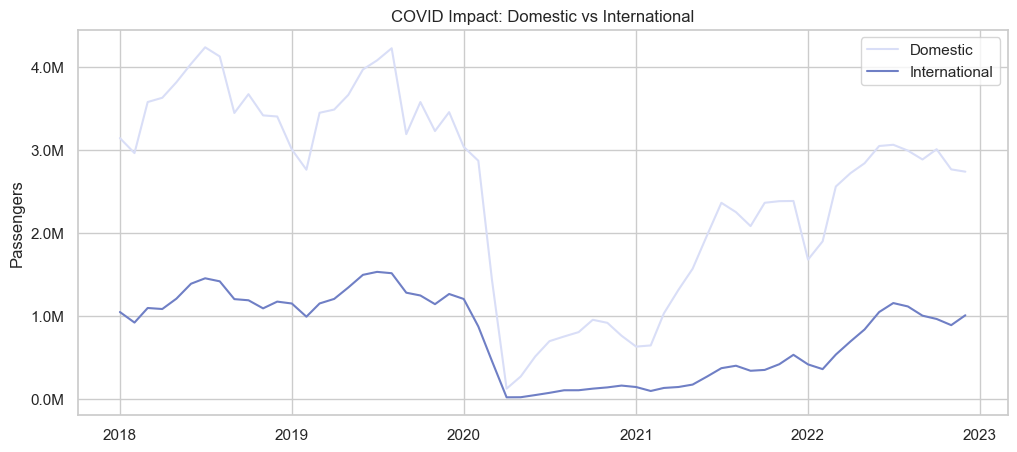

In [37]:
plt.figure(figsize=(12,5))

plt.plot(
    covid_types.index,
    covid_types['Domestic'],
    color='#D9DEF7',
    label='Domestic'
)

plt.plot(
    covid_types.index,
    covid_types['International'],
    color='#6F7FC5',
    label='International'
)

plt.title('COVID Impact: Domestic vs International')

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

plt.ylabel('Passengers')
plt.legend()

plt.show()

In [38]:
share = traffic_type.div(traffic_type.sum(axis=1), axis=0)

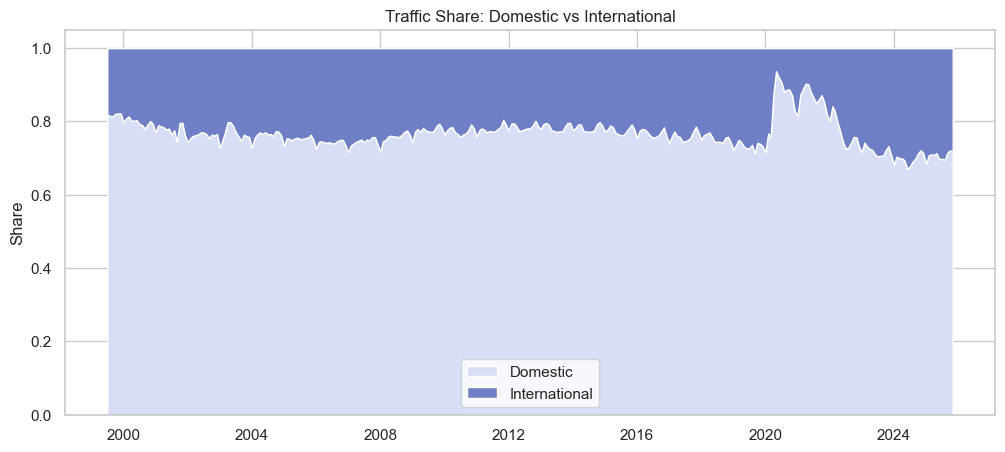

In [39]:
plt.figure(figsize=(12,5))

plt.stackplot(
    share.index,
    share['Domestic'],
    share['International'],
    labels=['Domestic', 'International'],
    colors=['#D9DEF7', '#6F7FC5']
)

plt.title('Traffic Share: Domestic vs International')
plt.ylabel('Share')
plt.legend()

plt.show()

In [41]:
# Analysis Plan
# 📊 1. Overall passenger dynamics by region
# 📊 2. Top regions by traffic
# 📊 3. Region share over time
# 📊 4. COVID impact by region
# 📊 5. Domestic vs. International within regions

In [42]:
# STEP 1 . Overall passenger dynamics by region
# Aggregate data

region_ts = (
    df.groupby(['Activity Period Start Date', 'GEO Region'])['Passenger Count']
      .sum()
      .unstack()
      .sort_index()
)

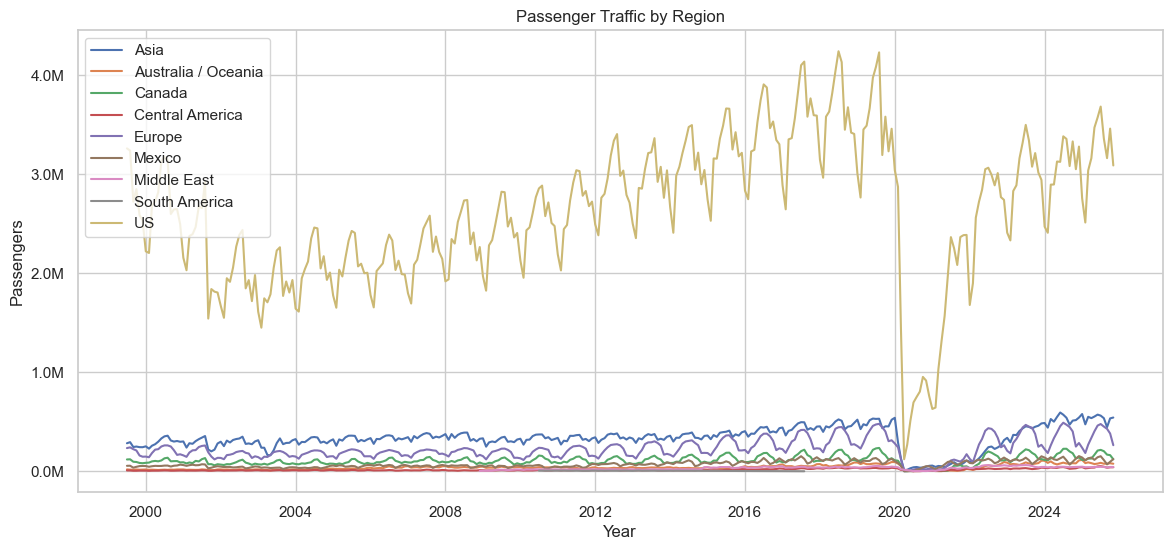

In [43]:
# Seaborn Line

sns.set(style='whitegrid')

plt.figure(figsize=(14,6))

for region in region_ts.columns:
    sns.lineplot(
        x=region_ts.index,
        y=region_ts[region],
        label=region
    )

plt.title('Passenger Traffic by Region')
plt.ylabel('Passengers')
plt.xlabel('Year')
ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
plt.show()

In [44]:
# STEP 2 – Top regions by traffic

top_regions = (
    region_ts.sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

region_top = region_ts[top_regions]

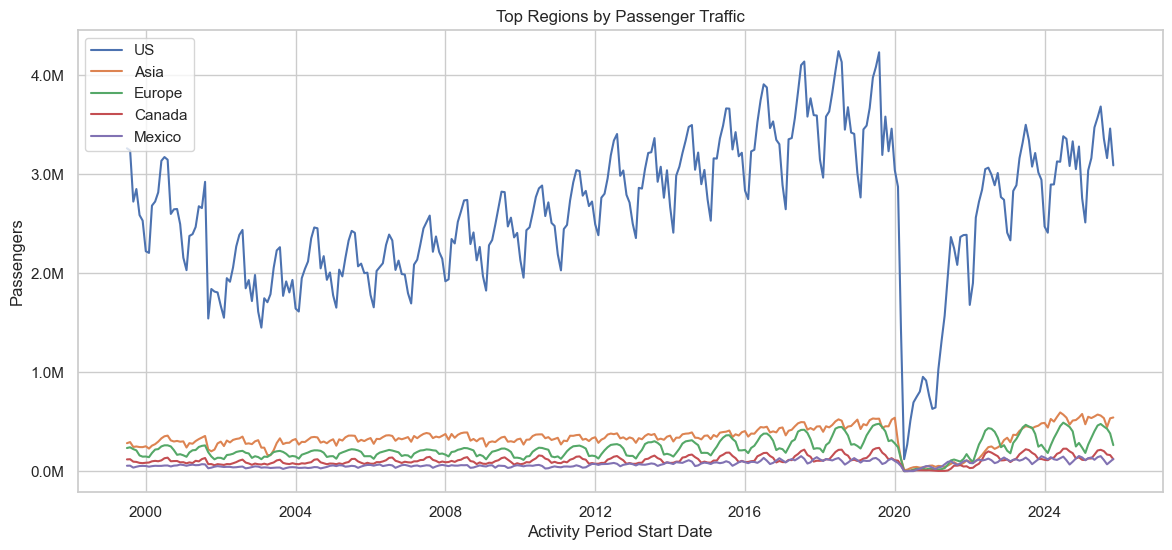

In [45]:
plt.figure(figsize=(14,6))

for region in region_top.columns:
    sns.lineplot(
        x=region_top.index,
        y=region_top[region],
        label=region
    )

plt.title('Top Regions by Passenger Traffic')
plt.ylabel('Passengers')

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

plt.show()

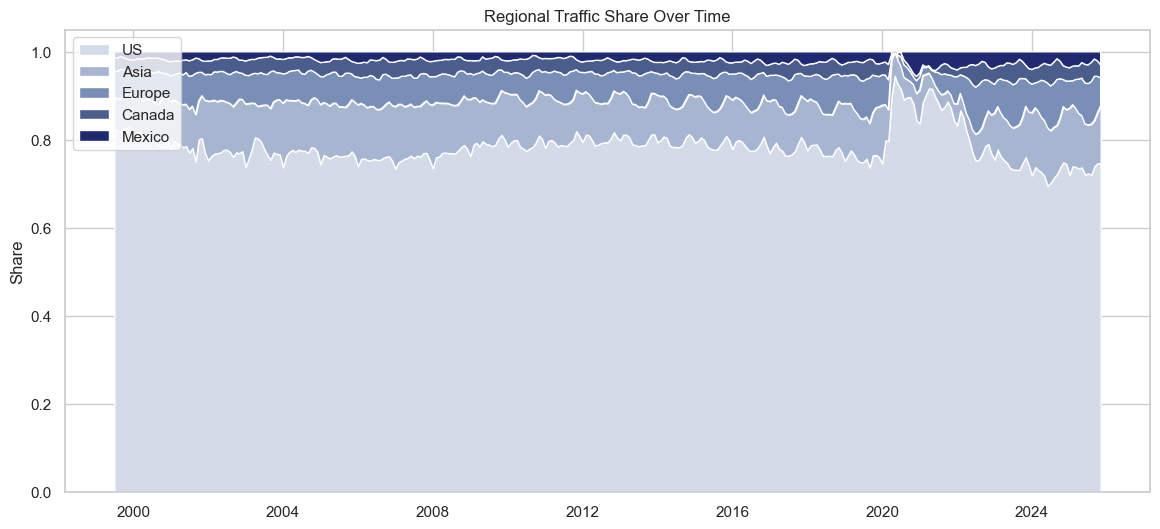

In [46]:
# STEP — Region share over time

share_region = region_top.div(region_top.sum(axis=1), axis=0)  # convert counts to shares

# sort regions by average share (largest first)
order = share_region.mean().sort_values(ascending=False).index
share_region = share_region[order]

plt.figure(figsize=(14,6))

# light → dark corporate blue-grey palette
colors = [
    "#D3DAE8",  # very light
    "#A8B5D1",
    "#7A8FB8",
    "#4A5D8C",
    "#1F2A70"   # dark navy
]

plt.stackplot(
    share_region.index,
    [share_region[col] for col in share_region.columns],
    labels=share_region.columns,
    colors=colors[:len(share_region.columns)]
)

plt.title('Regional Traffic Share Over Time')
plt.ylabel('Share')

plt.legend(loc='upper left')

plt.show()

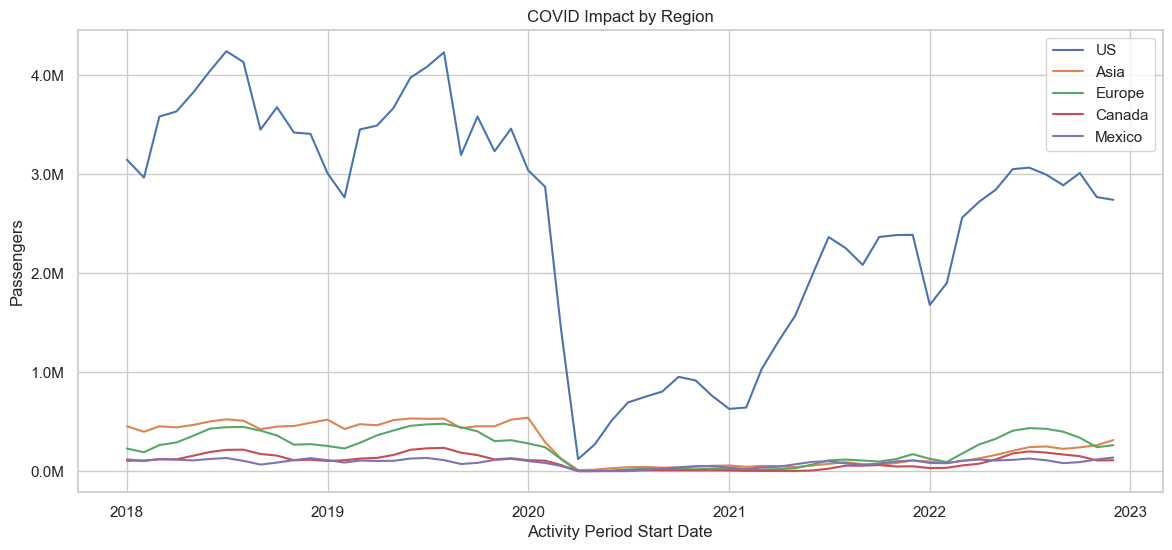

In [47]:
# STEP 4 - COVID impact by region

covid_region = region_top['2018':'2022']

plt.figure(figsize=(14,6))

for region in covid_region.columns:
    sns.lineplot(
        x=covid_region.index,
        y=covid_region[region],
        label=region
    )

plt.title('COVID Impact by Region')
plt.ylabel('Passengers')

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)
plt.show()

In [48]:
# Seasonality by Region (month-of-year x GEO Summary) ---

tmp = df.copy()
tmp['Activity Period Start Date'] = pd.to_datetime(tmp['Activity Period Start Date'], errors='coerce')
tmp = tmp.dropna(subset=['Activity Period Start Date'])

tmp['Month'] = tmp['Activity Period Start Date'].dt.month
tmp['GEO Summary'] = tmp['GEO Summary'].astype(str).str.strip()

season_region = (
    tmp.groupby(['Month', 'GEO Summary'])['Passenger Count']
       .mean()
       .unstack()
       .sort_index()
)

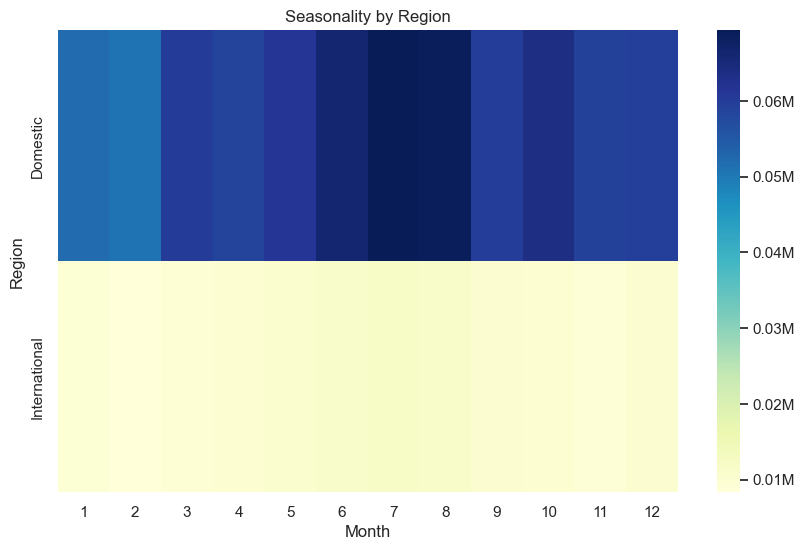

In [49]:
plt.figure(figsize=(10,6))

ax = sns.heatmap(
    season_region.T,
    cmap='YlGnBu',
    cbar_kws={'format': ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.2f}M')}
)

plt.title('Seasonality by Region')
plt.xlabel('Month')
plt.ylabel('Region')

plt.show()

In [50]:
# STEP 5: Domestic vs International within regions

region_type_ts = (
    df.groupby(['Activity Period Start Date', 'GEO Region', 'GEO Summary'])['Passenger Count']
      .sum()
      .reset_index()
)

region_type_ts.head()

,Activity Period Start Date,GEO Region,GEO Summary,Passenger Count
0,1999-07-01,Asia,International,282607
1,1999-07-01,Australia / Oceania,International,18656
2,1999-07-01,Canada,International,119032
3,1999-07-01,Central America,International,8337
4,1999-07-01,Europe,International,233872


In [51]:
pivot_rt = (
    region_type_ts.pivot_table(
        index='Activity Period Start Date',
        columns=['GEO Region', 'GEO Summary'],
        values='Passenger Count',
        aggfunc='sum'
    )
    .sort_index()
)

In [52]:
# Top 5 regions by total traffic
top_regions = (
    df.groupby('GEO Region')['Passenger Count']
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .index
)

top_regions

Index(['US', 'Asia', 'Europe', 'Canada', 'Mexico'], dtype='object', name='GEO Region')

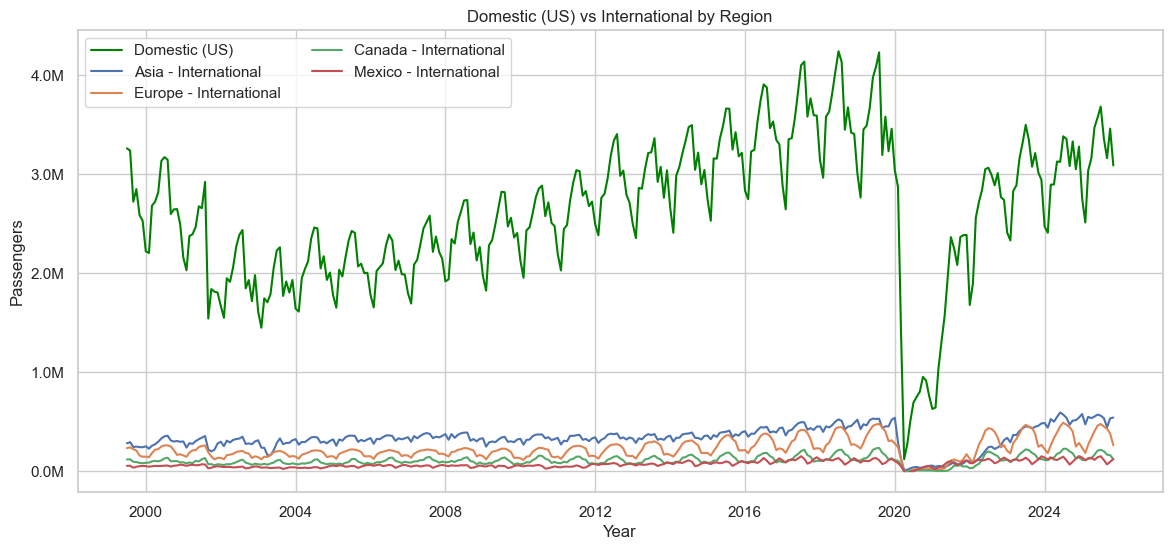

In [53]:
# Visual: two lines for each region (Domestic vs International)

sns.set(style='whitegrid')
plt.figure(figsize=(14,6))

# Domestic traffic (typically US only)
if 'Domestic' in traffic_type.columns:
    plt.plot(
        traffic_type.index,
        traffic_type['Domestic'],
        color='green',
        label='Domestic (US)'
    )

# International traffic for top regions
for region in top_regions:
    col = (region, 'International')
    if col in pivot_rt.columns:
        plt.plot(
            pivot_rt.index,
            pivot_rt[col],
            label=f'{region} - International'
        )

plt.title('Domestic (US) vs International by Region')
plt.xlabel('Year')
plt.ylabel('Passengers')

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

plt.legend(ncol=2)
plt.show()

In [54]:
region_flow = (
    df.groupby(['Activity Period Start Date','GEO Region','Activity Type Code'])['Passenger Count']
      .sum()
      .reset_index()
      .pivot_table(
          index='Activity Period Start Date',
          columns=['GEO Region','Activity Type Code'],
          values='Passenger Count',
          aggfunc='sum'
      )
      .sort_index()
)

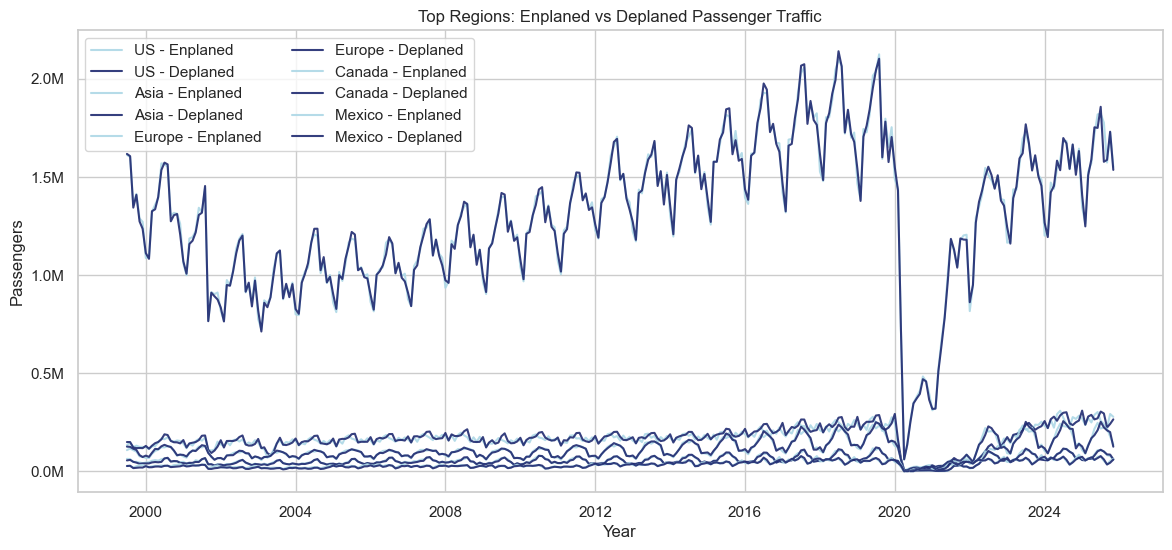

In [55]:
sns.set(style='whitegrid')
plt.figure(figsize=(14,6))

for region in top_regions:
    for flow, color in [('Enplaned','lightblue'), ('Deplaned','#1F2A70')]:
        col = (region, flow)
        if col in region_flow.columns:
            plt.plot(region_flow.index, region_flow[col], label=f'{region} - {flow}', color=color, alpha=0.9)

plt.title('Top Regions: Enplaned vs Deplaned Passenger Traffic')
plt.xlabel('Year')
plt.ylabel('Passengers')

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

plt.legend(ncol=2)
plt.show()